# Summary Statistics and Logistics Diagnostics

This notebook builds a first-pass analytical view of the marketplace and highlights the logistics issues that appear to be driving customer pain, especially cross-state delivery friction and late orders.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

BASE = Path('dataset/dataset')

In [2]:
orders = pd.read_csv(BASE / 'marketplace_transactions.csv', parse_dates=['purchase_timestamp','approved_at','shipped_date','delivered_date','estimated_delivery_date'])
payments = pd.read_csv(BASE / 'payments.csv')
feedback = pd.read_csv(BASE / 'feedback.csv', parse_dates=['feedback_date','response_timestamp'])
details = pd.read_csv(BASE / 'transaction_details.csv', parse_dates=['shipping_limit_date'])
items = pd.read_csv(BASE / 'items.csv')
translations = pd.read_csv(BASE / 'item_category_translation.csv')
buyers = pd.read_csv(BASE / 'buyers.csv')
artisans = pd.read_csv(BASE / 'artisans.csv')
location_data = pd.read_csv(BASE / 'location_data.csv')

print({
    'orders': orders.shape,
    'payments': payments.shape,
    'feedback': feedback.shape,
    'details': details.shape,
    'items': items.shape,
    'buyers': buyers.shape,
    'artisans': artisans.shape,
    'location_data': location_data.shape,
})

{'orders': (99441, 8), 'payments': (103886, 5), 'feedback': (99224, 7), 'details': (112650, 7), 'items': (32951, 9), 'buyers': (99441, 5), 'artisans': (3095, 4), 'location_data': (1000163, 5)}


## Data quality and table coverage

This section checks duplicate rows, missingness, and a few known caveats before analysis.

In [3]:
tables = {
    'artisans': artisans,
    'buyers': buyers,
    'feedback': feedback,
    'item_category_translation': translations,
    'items': items,
    'location_data': location_data,
    'marketplace_transactions': orders,
    'payments': payments,
    'transaction_details': details,
}

profile_rows = []
for name, df in tables.items():
    missing_pct = (df.isna().mean() * 100).round(2)
    profile_rows.append({
        'table': name,
        'rows': len(df),
        'cols': len(df.columns),
        'duplicate_rows': int(df.duplicated().sum()),
        'columns_with_missing': int((missing_pct > 0).sum()),
        'max_missing_pct': float(missing_pct.max()) if len(missing_pct) else 0.0,
    })

profile = pd.DataFrame(profile_rows).sort_values('rows', ascending=False)
profile

,table,rows,cols,duplicate_rows,columns_with_missing,max_missing_pct
5,location_data,1000163,5,261831,0,0.000
8,transaction_details,112650,7,0,0,0.000
7,payments,103886,5,0,0,0.000
1,buyers,99441,5,0,0,0.000
6,marketplace_transactions,99441,8,0,3,2.980
2,feedback,99224,7,0,2,88.340
4,items,32951,9,0,8,1.850
0,artisans,3095,4,0,0,0.000
3,item_category_translation,71,2,0,0,0.000


In [4]:
issues = {
    'feedback_unique_transactions': feedback['transaction_id'].nunique(),
    'feedback_transactions_with_multiple_reviews': int((feedback['transaction_id'].value_counts() > 1).sum()),
    'location_unique_zip_prefix': location_data['zip_code_prefix'].nunique(),
    'location_rows_per_zip_avg': round(len(location_data) / location_data['zip_code_prefix'].nunique(), 2),
    'items_missing_category_rows': int(items['item_category_name'].isna().sum()),
}
issues

{'feedback_unique_transactions': 98673,
 'feedback_transactions_with_multiple_reviews': 547,
 'location_unique_zip_prefix': 19015,
 'location_rows_per_zip_avg': 52.6,
 'items_missing_category_rows': 610}

## Analytical Table

`transaction_details.csv` is line-item level, so the notebook aggregates it to one row per transaction before joining to orders, payments, buyers, sellers, and reviews.

In [5]:
feedback_one = feedback.sort_values(['transaction_id','feedback_date']).drop_duplicates('transaction_id', keep='last')[['transaction_id','rating_score']]

line = details.merge(items[['item_id','item_category_name','item_weight_g']], on='item_id', how='left')
line = line.merge(translations, on='item_category_name', how='left')
line['category'] = line['item_category_name_english'].fillna(line['item_category_name'])
line = line.merge(artisans[['artisan_id','artisan_state','artisan_city']], on='artisan_id', how='left')

def pick_mode(series):
    mode = series.mode(dropna=True)
    if len(mode):
        return mode.iloc[0]
    series = series.dropna()
    return series.iloc[0] if len(series) else np.nan

order_lines = line.groupby('transaction_id').agg(
    items=('transaction_item_id', 'size'),
    artisans=('artisan_id', 'nunique'),
    order_price=('price', 'sum'),
    order_ship=('shipping_cost', 'sum'),
    total_weight=('item_weight_g', 'sum'),
    category=('category', pick_mode),
    artisan_state=('artisan_state', pick_mode),
    artisan_city=('artisan_city', pick_mode),
).reset_index()

payment_order = payments.groupby('transaction_id').agg(
    payment_amount=('payment_amount', 'sum'),
    payment_installments=('payment_installments', 'max'),
    payment_method=('payment_method', pick_mode),
    payment_rows=('payment_sequential', 'size'),
).reset_index()

order = (orders
    .merge(order_lines, on='transaction_id', how='left')
    .merge(payment_order, on='transaction_id', how='left')
    .merge(buyers[['buyer_id','buyer_unique_id','buyer_state','buyer_city']], on='buyer_id', how='left')
    .merge(feedback_one, on='transaction_id', how='left'))

order['gross_value'] = order['order_price'] + order['order_ship']
order['delivery_days'] = (order['delivered_date'] - order['purchase_timestamp']).dt.total_seconds() / 86400
order['approval_hours'] = (order['approved_at'] - order['purchase_timestamp']).dt.total_seconds() / 3600
order['late'] = order['delivered_date'] > order['estimated_delivery_date']
order['cross_state'] = order['buyer_state'] != order['artisan_state']
order['purchase_month'] = order['purchase_timestamp'].dt.to_period('M').astype(str)
order[['transaction_id','gross_value','delivery_days','late','cross_state','rating_score']].head()

,transaction_id,gross_value,delivery_days,late,cross_state,rating_score
0,e481f51cbdc54678b7cc49136f2d6af7,38.710,8.437,False,False,4.000
1,53cdb2fc8bc7dce0b6741e2150273451,141.460,13.782,False,True,4.000
2,47770eb9100c2d0c44946d9cf07ec65d,179.120,9.394,False,True,5.000
3,949d5b44dbf5de918fe9c16f97b45f8a,72.200,13.209,False,True,5.000
4,ad21c59c0840e6cb83a9ceb5573f8159,28.620,2.874,False,False,5.000


## Core summary statistics

In [6]:
summary = {
    'transactions': len(order),
    'unique_buyers': order['buyer_unique_id'].nunique(),
    'delivered_share_pct': round(order['transaction_status'].eq('delivered').mean() * 100, 2),
    'repeat_buyer_pct': round(order.groupby('buyer_unique_id').size().gt(1).mean() * 100, 2),
    'single_item_order_pct': round(order['items'].eq(1).mean() * 100, 2),
    'single_artisan_order_pct': round(order['artisans'].eq(1).mean() * 100, 2),
    'avg_order_value': round(order['gross_value'].mean(), 2),
    'median_order_value': round(order['gross_value'].median(), 2),
    'avg_rating': round(order['rating_score'].mean(), 3),
}
summary

{'transactions': 99441,
 'unique_buyers': 96096,
 'delivered_share_pct': np.float64(97.02),
 'repeat_buyer_pct': np.float64(3.12),
 'single_item_order_pct': np.float64(89.36),
 'single_artisan_order_pct': np.float64(97.94),
 'avg_order_value': np.float64(160.58),
 'median_order_value': np.float64(105.29),
 'avg_rating': np.float64(4.086)}

In [7]:
monthly = order.groupby('purchase_month').agg(orders=('transaction_id','size'), gmv=('gross_value','sum')).reset_index()
monthly = monthly[(monthly['purchase_month'] >= '2017-01') & (monthly['purchase_month'] <= '2018-08')]
monthly.tail()

,purchase_month,orders,gmv
18,2018-04,6939,"1,159,698.040"
19,2018-05,6873,"1,149,781.820"
20,2018-06,6167,"1,022,677.110"
21,2018-07,6292,"1,058,728.030"
22,2018-08,6512,"1,003,308.470"


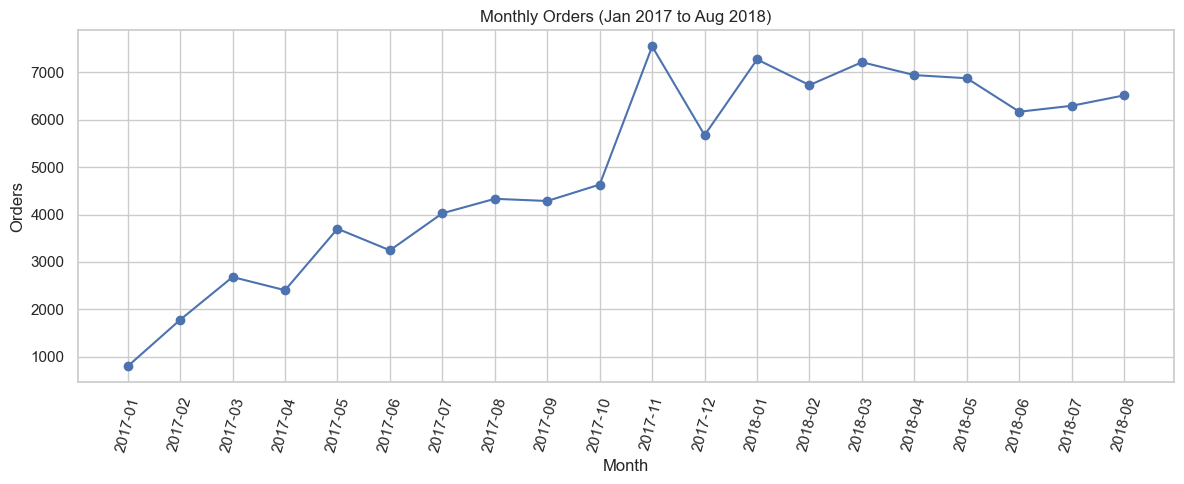

In [8]:
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(monthly['purchase_month'], monthly['orders'], marker='o', label='Orders')
ax1.set_title('Monthly Orders (Jan 2017 to Aug 2018)')
ax1.set_xlabel('Month')
ax1.set_ylabel('Orders')
ax1.tick_params(axis='x', rotation=75)
plt.tight_layout()

## Geography and logistics concentration

In [9]:
buyer_state = buyers['buyer_state'].value_counts().rename_axis('state').reset_index(name='buyers')
artisan_state = artisans['artisan_state'].value_counts().rename_axis('state').reset_index(name='artisans')
state_mix = buyer_state.merge(artisan_state, on='state', how='outer').fillna(0)
state_mix['buyers_share_pct'] = state_mix['buyers'] / state_mix['buyers'].sum() * 100
state_mix['artisans_share_pct'] = state_mix['artisans'] / state_mix['artisans'].sum() * 100
state_mix.sort_values('buyers', ascending=False).head(12)

,state,buyers,artisans,buyers_share_pct,artisans_share_pct
25,SP,41746,"1,849.000",41.981,59.742
18,RJ,12852,171.000,12.924,5.525
10,MG,11635,244.000,11.700,7.884
22,RS,5466,129.000,5.497,4.168
17,PR,5045,349.000,5.073,11.276
23,SC,3637,190.000,3.657,6.139
4,BA,3380,19.000,3.399,0.614
6,DF,2140,30.000,2.152,0.969
7,ES,2033,23.000,2.044,0.743
8,GO,2020,40.000,2.031,1.292


In [10]:
cross_state_perf = order.dropna(subset=['cross_state']).groupby('cross_state').agg(
    orders=('transaction_id', 'size'),
    avg_order=('gross_value', 'mean'),
    avg_delivery=('delivery_days', 'mean'),
    late_rate=('late', 'mean'),
    avg_rating=('rating_score', 'mean'),
).reset_index()
cross_state_perf['cross_state'] = cross_state_perf['cross_state'].map({False: 'Same-state', True: 'Cross-state'})
cross_state_perf

,cross_state,orders,avg_order,avg_delivery,late_rate,avg_rating
0,Same-state,35430,135.079,7.946,0.059,4.211
1,Cross-state,64011,174.864,15.144,0.089,4.017


/var/folders/wd/s3nvdbj97g1bv1v4bsgwg8hr0000gn/T/ipykernel_2631/1248723918.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Same-state', 'Cross-state'])
/var/folders/wd/s3nvdbj97g1bv1v4bsgwg8hr0000gn/T/ipykernel_2631/1248723918.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Same-state', 'Cross-state'])
/var/folders/wd/s3nvdbj97g1bv1v4bsgwg8hr0000gn/T/ipykernel_2631/1248723918.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(['Same-state', 'Cross-state'])


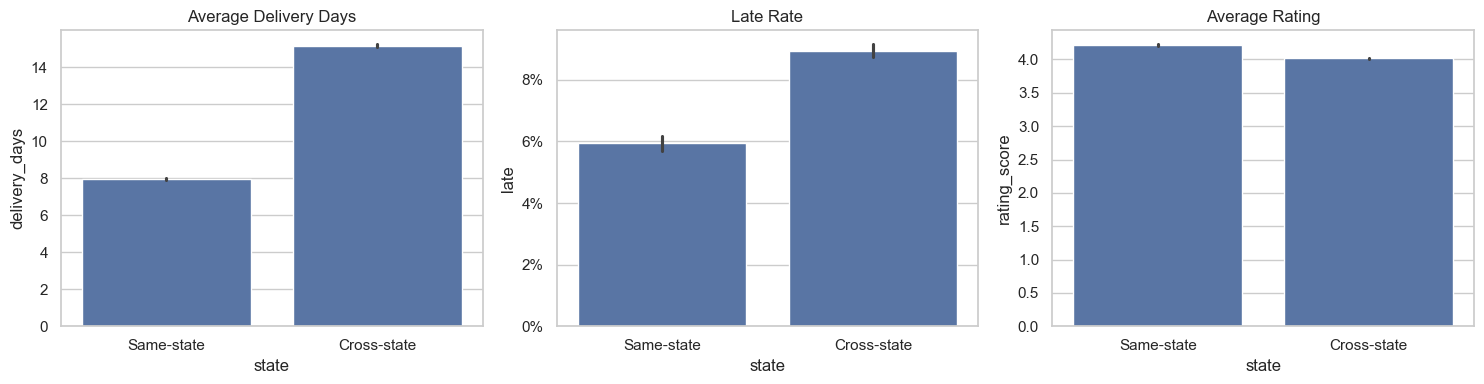

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_df = order.dropna(subset=['cross_state'])
sns.barplot(data=plot_df, x='cross_state', y='delivery_days', estimator='mean', ax=axes[0])
axes[0].set_title('Average Delivery Days')
axes[0].set_xticklabels(['Same-state', 'Cross-state'])
axes[0].set_xlabel('state')

sns.barplot(data=plot_df, x='cross_state', y='late', estimator='mean', ax=axes[1])
axes[1].set_title('Late Rate')
axes[1].set_xticklabels(['Same-state', 'Cross-state'])
axes[1].set_xlabel('state')
axes[1].yaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')

sns.barplot(data=plot_df, x='cross_state', y='rating_score', estimator='mean', ax=axes[2])
axes[2].set_title('Average Rating')
axes[2].set_xticklabels(['Same-state', 'Cross-state'])
axes[2].set_xlabel('state')
plt.tight_layout()

### Logistics issue highlight

Cross-state fulfillment is the biggest structural logistics issue in the dataset. It is common, slower, later, and associated with lower ratings.

In [19]:
state_perf = order.groupby('buyer_state').agg(
    orders=('transaction_id', 'size'),
    avg_delivery=('delivery_days', 'mean'),
    late_rate=('late', 'mean'),
    avg_rating=('rating_score', 'mean'),
    avg_order=('gross_value', 'mean'),
).query('orders >= 1500').sort_values('late_rate', ascending=False)
state_perf.round(3)

,orders,avg_delivery,late_rate,avg_rating,avg_order
buyer_state,,,,,
BA,3380,19.335,0.135,3.861,182.104
RJ,12852,15.310,0.129,3.877,166.877
ES,2033,15.789,0.120,4.037,160.396
PE,1652,18.448,0.104,4.009,195.533
SC,3637,14.959,0.095,4.074,168.941
GO,2020,15.606,0.079,4.043,173.247
RS,5466,15.300,0.070,4.132,163.076
DF,2140,12.968,0.069,4.064,166.226
SP,41746,8.761,0.057,4.173,143.122


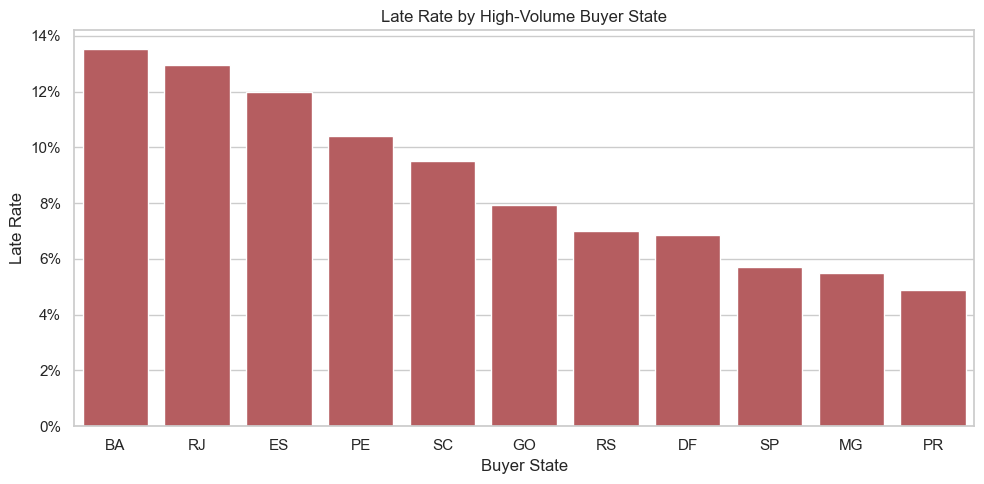

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
state_plot = state_perf.reset_index()
sns.barplot(data=state_plot, x='buyer_state', y='late_rate', ax=ax, color='#c44e52')
ax.set_title('Late Rate by High-Volume Buyer State')
ax.set_xlabel('Buyer State')
ax.set_ylabel('Late Rate')
ax.yaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
plt.tight_layout()

## Customer satisfaction and delivery performance

In [21]:
rating_by_late = order.dropna(subset=['rating_score']).groupby('late').agg(
    orders=('transaction_id', 'size'),
    avg_rating=('rating_score', 'mean')
)
rating_by_late.index = rating_by_late.index.map({False: 'On-time', True: 'Late'})
rating_by_late

,orders,avg_rating
late,,
On-time,91011,4.214
Late,7662,2.565


In [22]:
delivery_q = order.dropna(subset=['delivery_days','rating_score']).copy()
delivery_q['delivery_bucket'] = pd.qcut(delivery_q['delivery_days'], 4, duplicates='drop')
delivery_q.groupby('delivery_bucket').agg(orders=('transaction_id','size'), avg_rating=('rating_score','mean')).round(3)

/var/folders/wd/s3nvdbj97g1bv1v4bsgwg8hr0000gn/T/ipykernel_2631/234041391.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  delivery_q.groupby('delivery_bucket').agg(orders=('transaction_id','size'), avg_rating=('rating_score','mean')).round(3)


,orders,avg_rating
delivery_bucket,,
"(0.532, 6.758]",23958,4.420
"(6.758, 10.206]",23957,4.349
"(10.206, 15.664]",23957,4.258
"(15.664, 208.352]",23958,3.596


### Logistics issue highlight

Late delivery is the clearest observable driver of poor customer ratings in this dataset.

In [23]:
category_perf = order.groupby('category').agg(
    orders=('transaction_id', 'size'),
    avg_order=('gross_value', 'mean'),
    avg_delivery=('delivery_days', 'mean'),
    late_rate=('late', 'mean'),
    avg_rating=('rating_score', 'mean'),
    ship_share=('order_ship', lambda s: s.sum() / order.loc[s.index, 'gross_value'].sum())
).sort_values('orders', ascending=False).head(15)
category_perf.round(3)

,orders,avg_order,avg_delivery,late_rate,avg_rating,ship_share
category,,,,,,
bed_bath_table,9385,133.966,13.002,0.086,3.973,0.165
health_beauty,8810,163.818,12.093,0.088,4.184,0.127
sports_leisure,7668,150.494,12.260,0.076,4.177,0.146
computers_accessories,6679,159.276,13.178,0.075,4.027,0.139
furniture_decor,6350,142.819,13.116,0.084,4.024,0.191
housewares,5812,133.354,11.108,0.069,4.153,0.188
watches_gifts,5584,232.637,12.837,0.084,4.074,0.077
telephony,4177,94.271,12.976,0.083,4.009,0.180
auto,3891,176.724,12.339,0.084,4.090,0.135


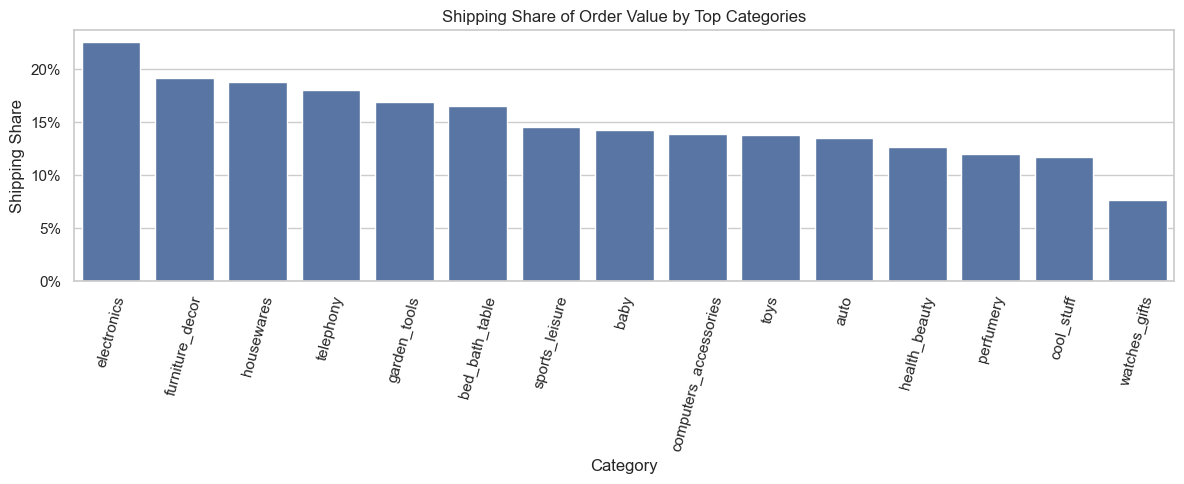

In [24]:
fig, ax = plt.subplots(figsize=(12, 5))
cat_plot = category_perf.reset_index().sort_values('ship_share', ascending=False)
sns.barplot(data=cat_plot, x='category', y='ship_share', ax=ax, color='#4c72b0')
ax.set_title('Shipping Share of Order Value by Top Categories')
ax.set_xlabel('Category')
ax.set_ylabel('Shipping Share')
ax.yaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
ax.tick_params(axis='x', rotation=75)
plt.tight_layout()

## What the summary statistics suggest

- The marketplace is growing, but logistics performance is uneven across states.
- Cross-state shipping is common and materially worse than same-state shipping.
- Late delivery is the strongest visible driver of low ratings.
- The most practical next step is to prioritize logistics interventions by seller, state, and category rather than trying to fix everything at once.